In [1]:
import yfinance as yf
data = yf.download("AAPL", start="2024-01-01", end="2024-12-31")
print(data.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.903229  186.677036  182.169601  185.399096  82488700
2024-01-03  182.526245  184.141000  181.713909  182.496527  58414500
2024-01-04  180.208130  181.377083  179.187767  180.445875  71983600
2024-01-05  179.484955  181.050175  178.484409  180.287390  62379700
2024-01-08  183.823990  183.863624  179.801976  180.386452  59144500


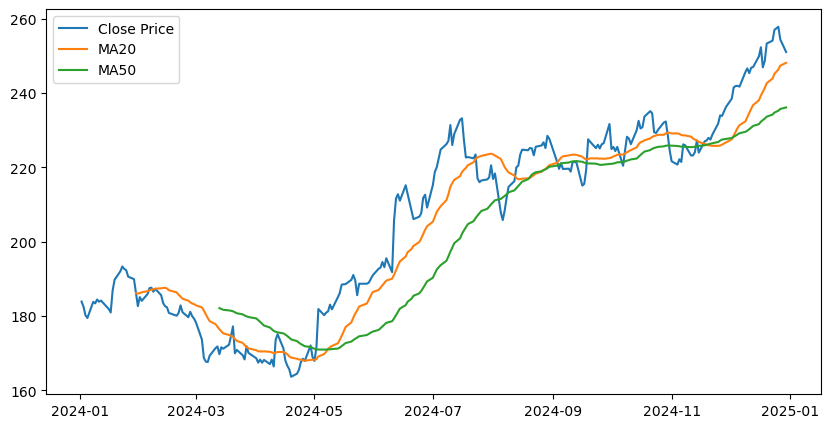

In [2]:
import matplotlib.pyplot as plt
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA20'], label='MA20')
plt.plot(data['MA50'], label='MA50')
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


交易次数: 2
每笔收益率: [Ticker
AAPL    0.242638
dtype: float64, Ticker
AAPL    0.002198
dtype: float64]
总收益率: Ticker
AAPL    0.244836
dtype: float64


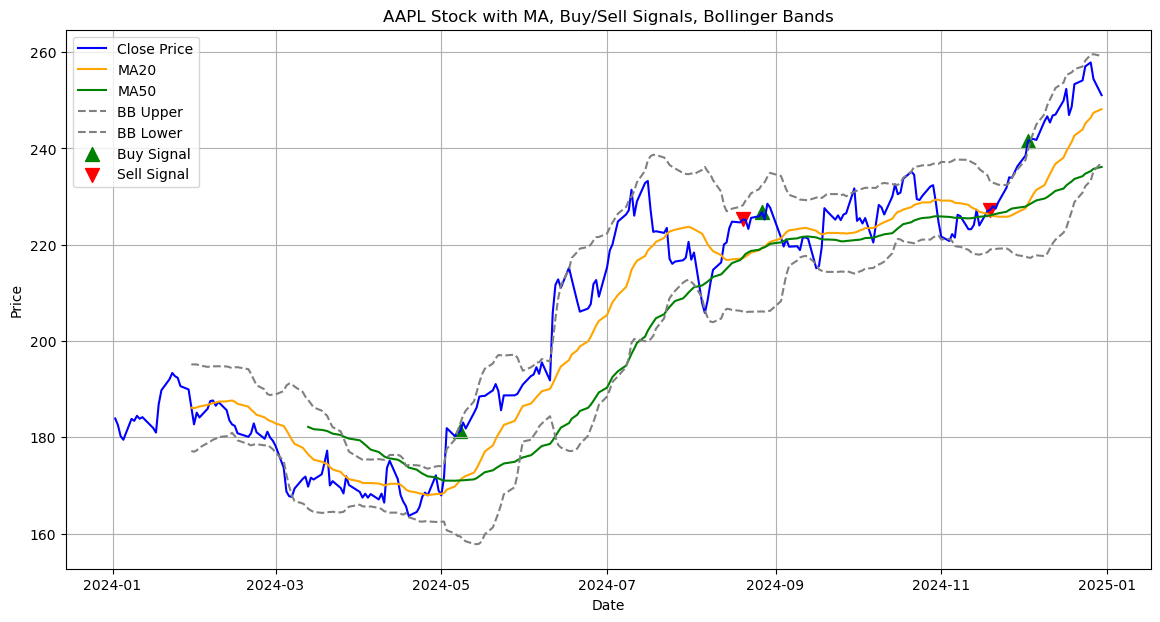

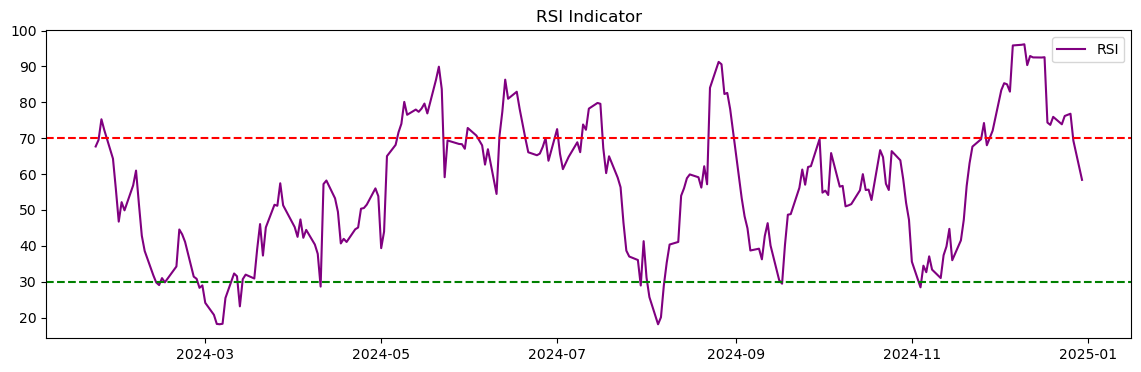

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 下载 AAPL 股票数据
data = yf.download("AAPL", start="2024-01-01", end="2024-12-31")

# 移动平均线
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

# 买卖信号
data['Buy'] = (data['MA20'] > data['MA50']) & (data['MA20'].shift(1) <= data['MA50'].shift(1))
data['Sell'] = (data['MA20'] < data['MA50']) & (data['MA20'].shift(1) >= data['MA50'].shift(1))

# 收益率计算
positions = []
buy_price = None
for i in range(len(data)):
    if data['Buy'].iloc[i]:
        buy_price = data['Close'].iloc[i]
    elif data['Sell'].iloc[i] and buy_price is not None:
        sell_price = data['Close'].iloc[i]
        positions.append((buy_price, sell_price))
        buy_price = None

returns = [(sell - buy) / buy for buy, sell in positions]
print("交易次数:", len(positions))
print("每笔收益率:", returns)
print("总收益率:", sum(returns))

# RSI
delta = data['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# 布林带（修正版本）
mid = data['Close'].rolling(20).mean()
std = data['Close'].rolling(20).std()
data['BB_Mid'] = mid
data['BB_Upper'] = mid + 2 * std
data['BB_Lower'] = mid - 2 * std

# 绘图
plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(data['MA20'], label='MA20', color='orange')
plt.plot(data['MA50'], label='MA50', color='green')
plt.plot(data['BB_Upper'], label='BB Upper', color='gray', linestyle='--')
plt.plot(data['BB_Lower'], label='BB Lower', color='gray', linestyle='--')

# 标注买卖信号
plt.scatter(data.index[data['Buy']], data['Close'][data['Buy']], marker='^', color='green', label='Buy Signal', s=100)
plt.scatter(data.index[data['Sell']], data['Close'][data['Sell']], marker='v', color='red', label='Sell Signal', s=100)

plt.title('AAPL Stock with MA, Buy/Sell Signals, Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# RSI 图
plt.figure(figsize=(14,4))
plt.plot(data['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('RSI Indicator')
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


Number of trades: 2
Returns per trade: [Ticker
AAPL    0.242638
dtype: float64, Ticker
AAPL    0.002198
dtype: float64]
Total return: Ticker
AAPL    0.244836
dtype: float64


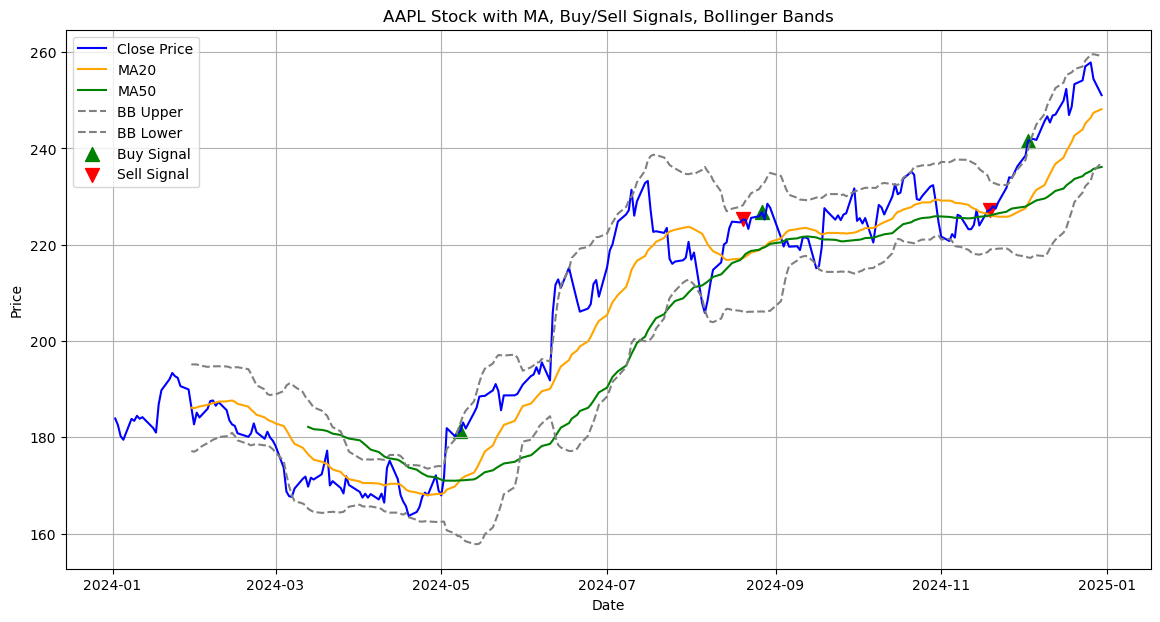

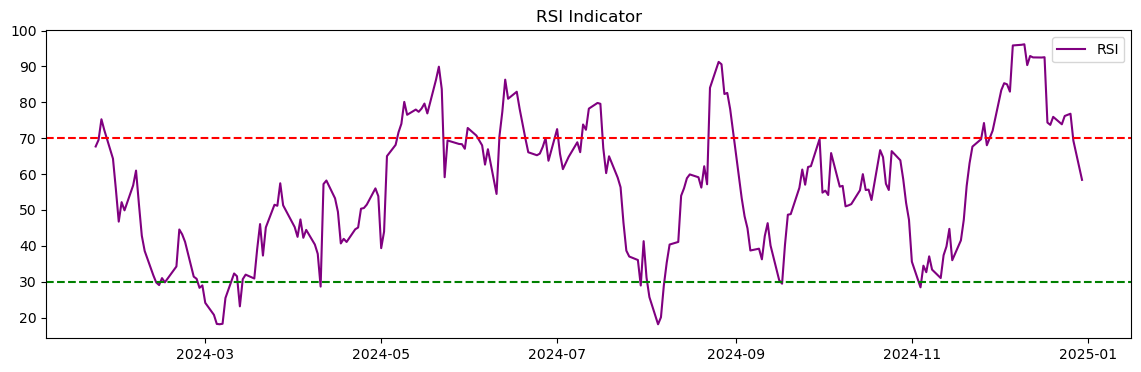

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Download stock data (Example: AAPL)
data = yf.download("AAPL", start="2024-01-01", end="2024-12-31")

# 2. Calculate moving averages: 20-day and 50-day
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

# 3. Generate trading signals:
# Buy when MA20 crosses above MA50
# Sell when MA20 crosses below MA50
data['Buy'] = (data['MA20'] > data['MA50']) & (data['MA20'].shift(1) <= data['MA50'].shift(1))
data['Sell'] = (data['MA20'] < data['MA50']) & (data['MA20'].shift(1) >= data['MA50'].shift(1))

# 4. Calculate returns based on signals:
# Assume buying at Buy signal and selling at next Sell signal
positions = []
buy_price = None
for i in range(len(data)):
    if data['Buy'].iloc[i]:
        buy_price = data['Close'].iloc[i]
    elif data['Sell'].iloc[i] and buy_price is not None:
        sell_price = data['Close'].iloc[i]
        positions.append((buy_price, sell_price))
        buy_price = None

# Compute percentage returns for each trade and total return
returns = [(sell - buy) / buy for buy, sell in positions]
print("Number of trades:", len(positions))
print("Returns per trade:", returns)
print("Total return:", sum(returns))

# 5. Calculate RSI (Relative Strength Index)
# RSI measures momentum: values above 70 = overbought, below 30 = oversold
delta = data['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# 6. Calculate Bollinger Bands:
# Middle band = 20-day moving average
# Upper band = Mid + 2 * standard deviation
# Lower band = Mid - 2 * standard deviation
mid = data['Close'].rolling(20).mean()
std = data['Close'].rolling(20).std()
data['BB_Mid'] = mid
data['BB_Upper'] = mid + 2 * std
data['BB_Lower'] = mid - 2 * std

# 7. Plot price, moving averages, Bollinger Bands, and buy/sell signals
plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(data['MA20'], label='MA20', color='orange')
plt.plot(data['MA50'], label='MA50', color='green')
plt.plot(data['BB_Upper'], label='BB Upper', color='gray', linestyle='--')
plt.plot(data['BB_Lower'], label='BB Lower', color='gray', linestyle='--')

# Mark buy signals with green upward arrows
plt.scatter(data.index[data['Buy']], data['Close'][data['Buy']], marker='^', color='green', label='Buy Signal', s=100)
# Mark sell signals with red downward arrows
plt.scatter(data.index[data['Sell']], data['Close'][data['Sell']], marker='v', color='red', label='Sell Signal', s=100)

plt.title('AAPL Stock with MA, Buy/Sell Signals, Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# 8. Plot RSI indicator
plt.figure(figsize=(14,4))
plt.plot(data['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--')   # Overbought threshold
plt.axhline(30, color='green', linestyle='--') # Oversold threshold
plt.title('RSI Indicator')
plt.legend()
plt.show()